<a href="https://colab.research.google.com/github/greeshmakrishnan00/EDA-ML-DL-Projects/blob/main/AI_BASED_HEART_ATTACK_PREDICTION_PROJECT_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement
 With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [ ]:
df=pd.read_csv("/content/Patients Data ( Used for Heart Disease Prediction ) (1).csv")
df

,tientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
df.isnull().sum()

,0
tientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(237630, 35)

In [ ]:
df.columns

Index(['tientID', 'State', 'Sex', 'GeneralHealth', 'AgeCategory',
       'HeightInMeters', 'WeightInKilograms', 'BMI', 'HadHeartAttack',
       'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   tientID                   237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
target='HadHeartAttack'

In [ ]:
df[target].value_counts()

,count
HadHeartAttack,
0,224429
1,13201


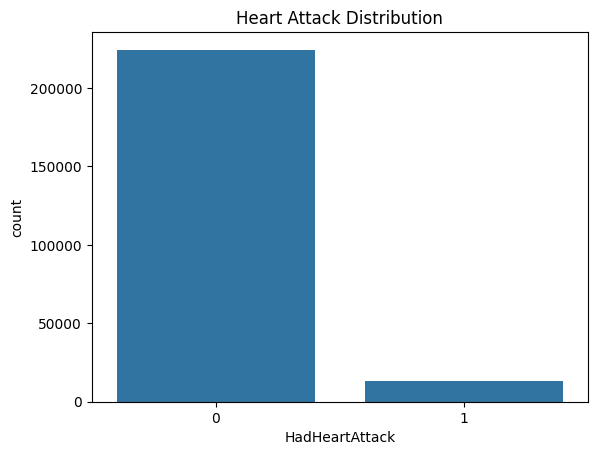

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='HadHeartAttack', data=df)
plt.title('Heart Attack Distribution')
plt.show()

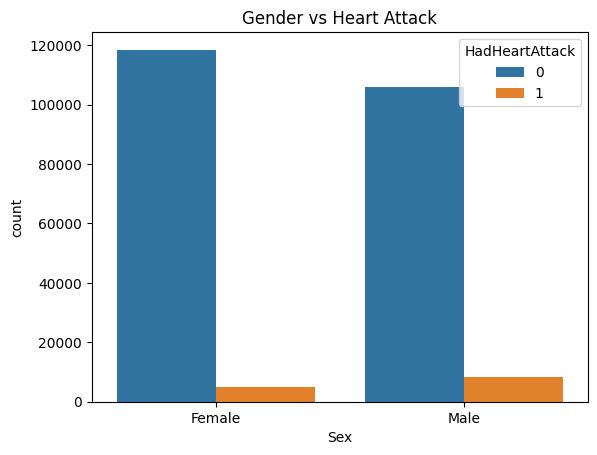

In [ ]:
sns.countplot(x='Sex', hue='HadHeartAttack', data=df)
plt.title('Gender vs Heart Attack')
plt.show()

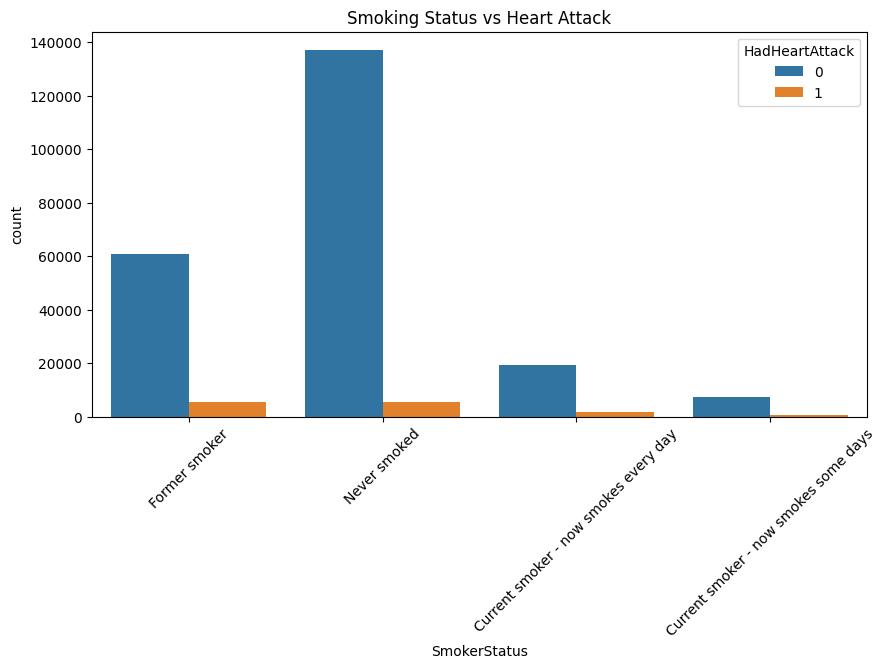

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='SmokerStatus', hue='HadHeartAttack', data=df)
plt.xticks(rotation=45)
plt.title('Smoking Status vs Heart Attack')
plt.show()

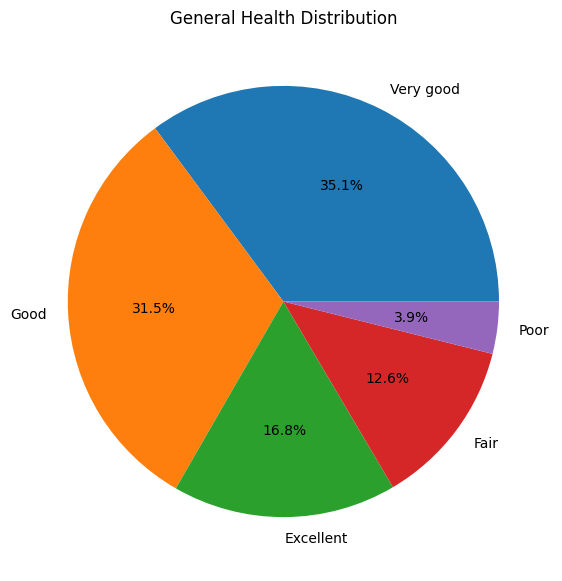

In [ ]:
import matplotlib.pyplot as plt

df['GeneralHealth'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title('General Health Distribution')
plt.ylabel('')
plt.show()

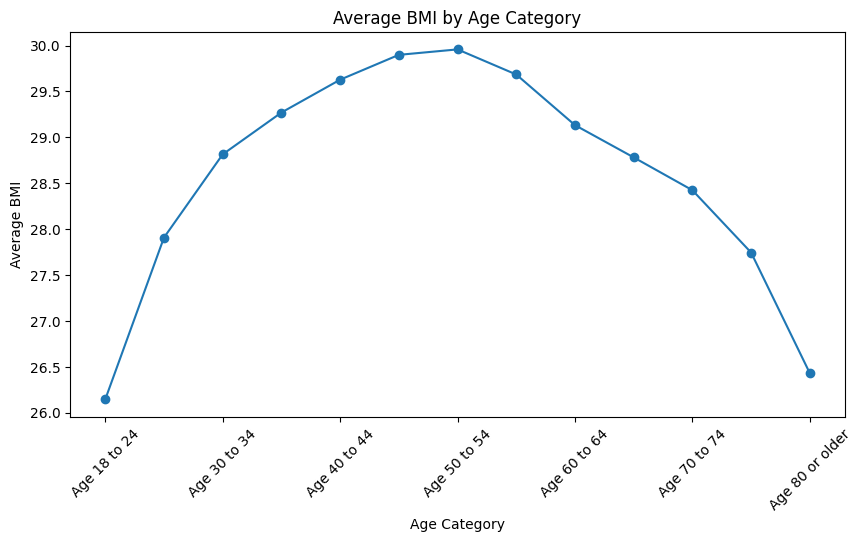

In [ ]:
avg_bmi = df.groupby('AgeCategory')['BMI'].mean()

plt.figure(figsize=(10,5))
avg_bmi.plot(kind='line', marker='o')
plt.title('Average BMI by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Average BMI')
plt.xticks(rotation=45)
plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['State', 'Sex', 'GeneralHealth', 'AgeCategory', 'HadDiabetes',
       'SmokerStatus', 'ECigaretteUsage', 'RaceEthnicityCategory',
       'TetanusLast10Tdap'],
      dtype='object')

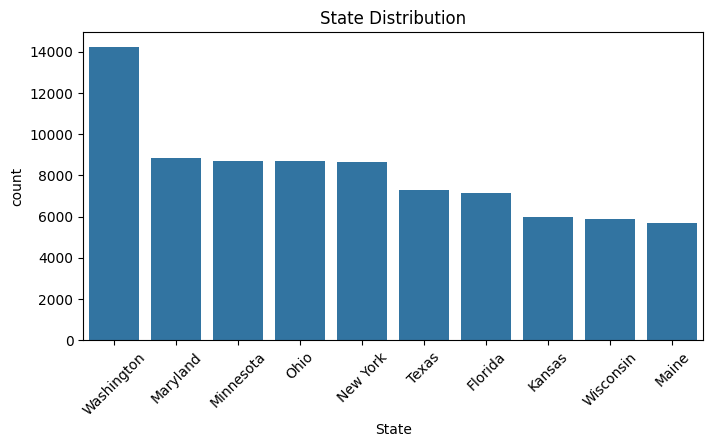

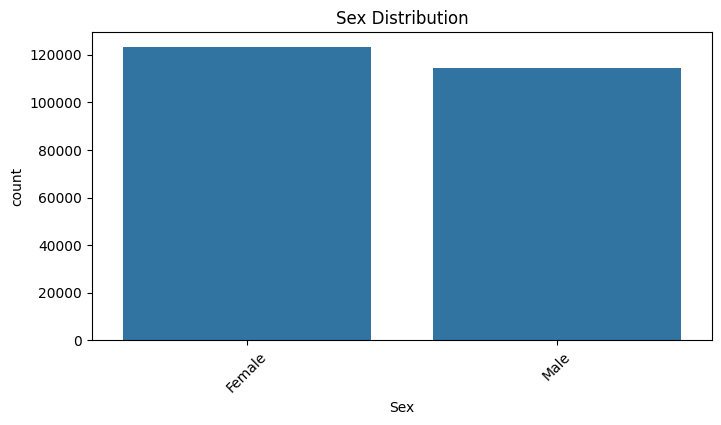

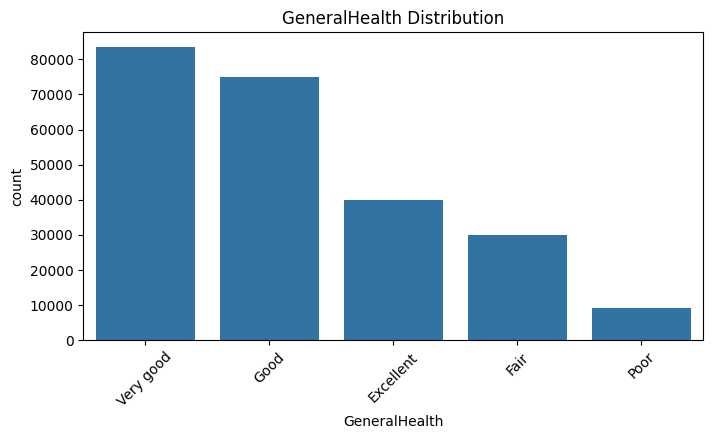

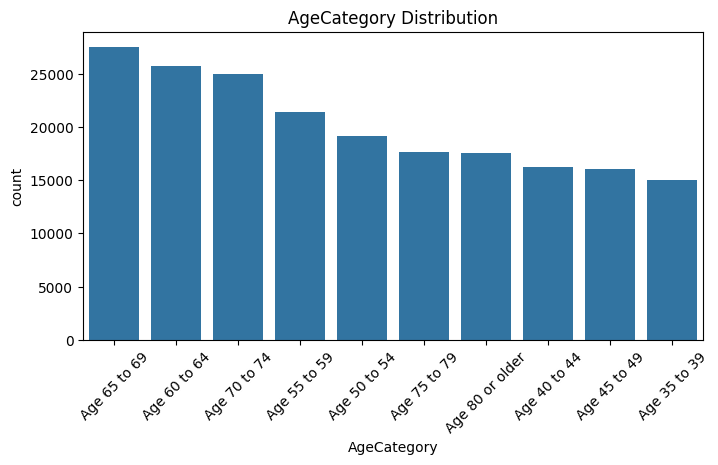

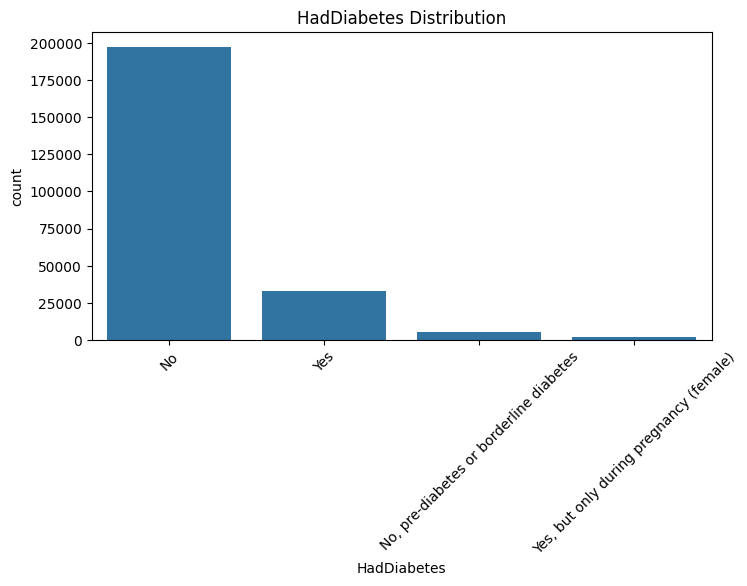

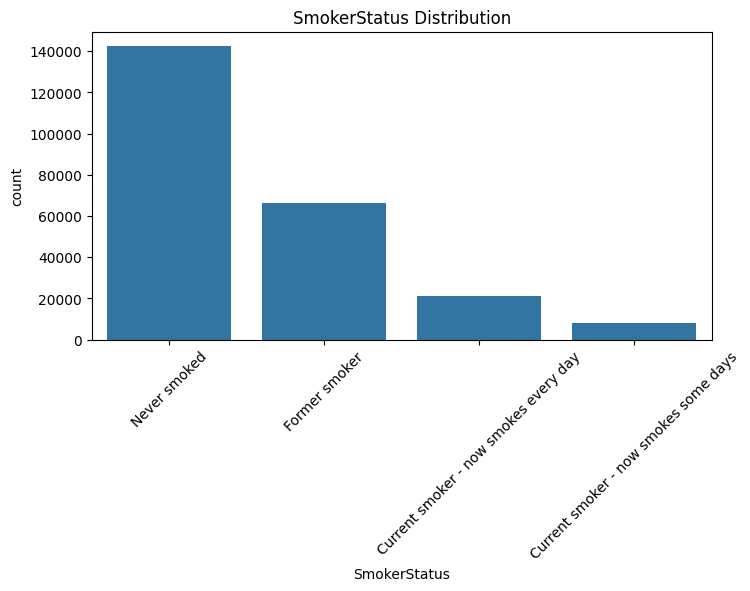

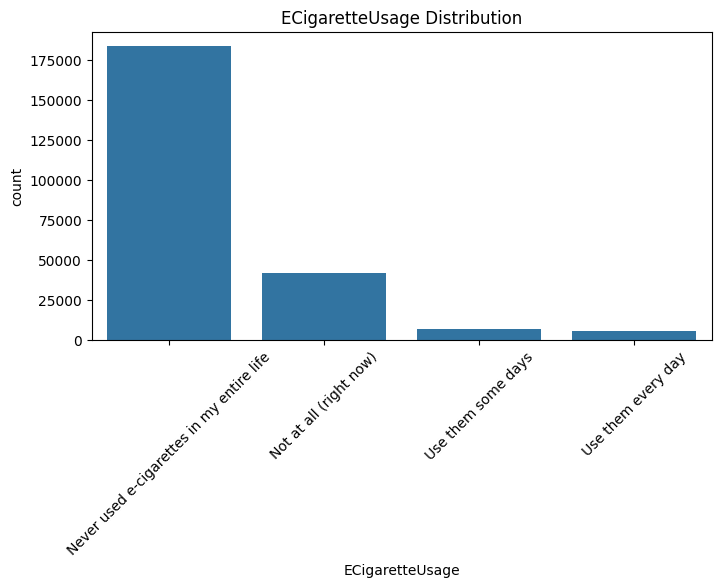

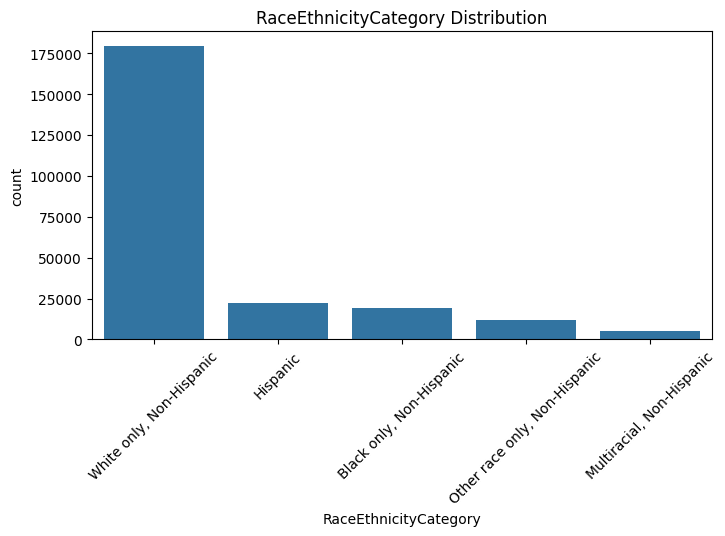

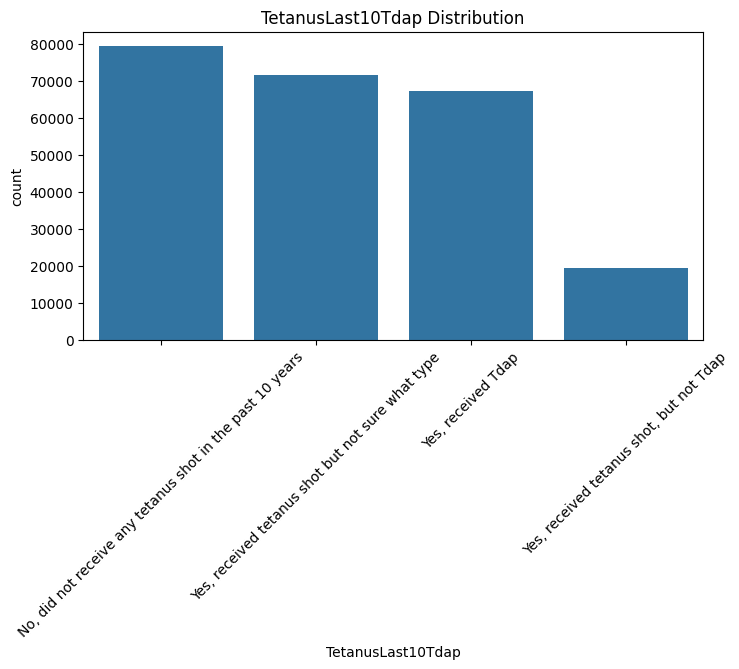

In [ ]:
for col in categorical_cols:
  plt.figure(figsize=(8,4))
  sns.countplot(x=df[col],order=df[col].value_counts().index[:10])
  plt.xticks(rotation=45)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['tientID', 'HeightInMeters', 'WeightInKilograms', 'BMI',
       'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma',
       'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease',
       'HadArthritis', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'ChestScan',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'HighRiskLastYear', 'CovidPos'],
      dtype='object')

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


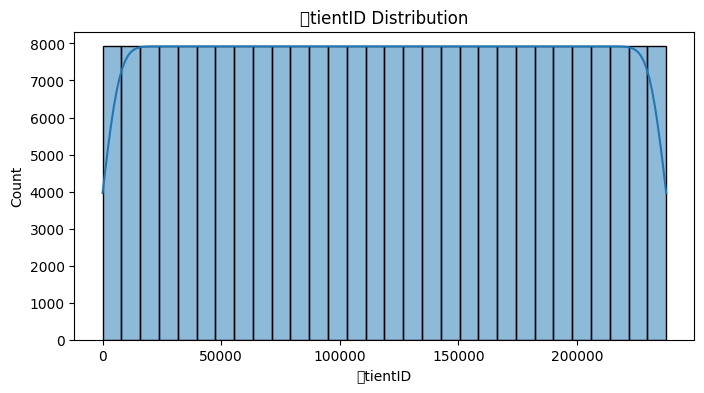

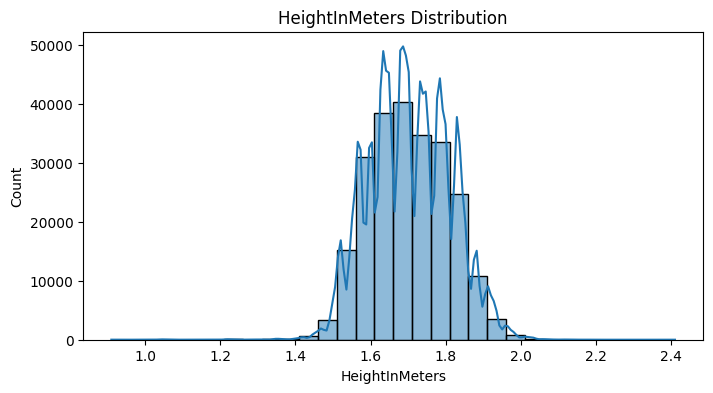

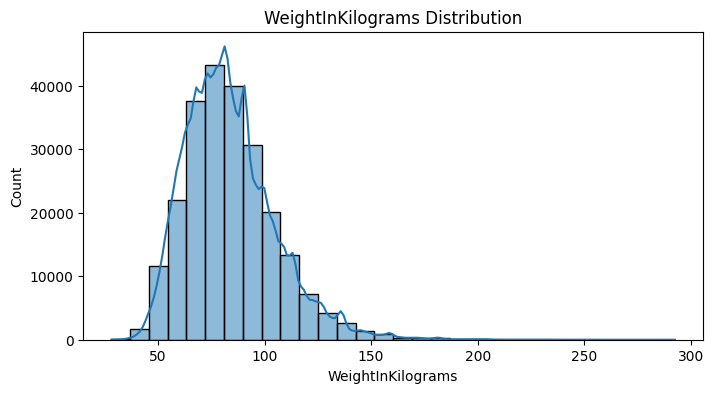

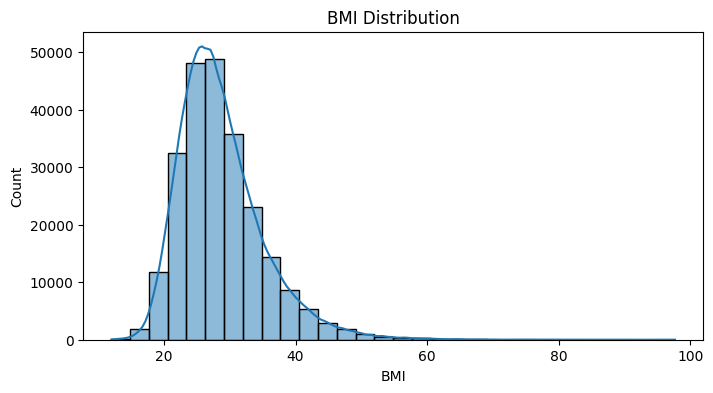

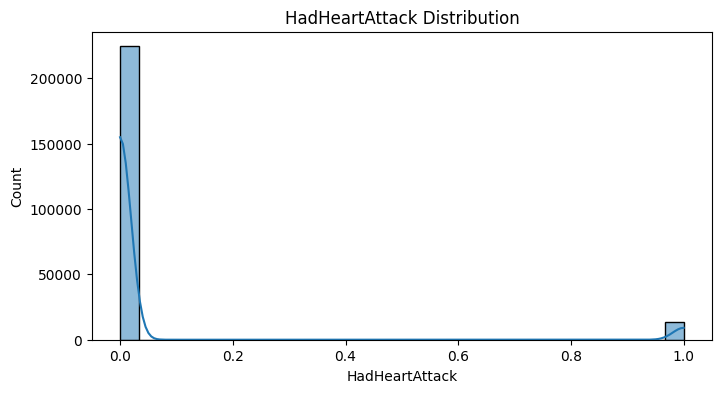

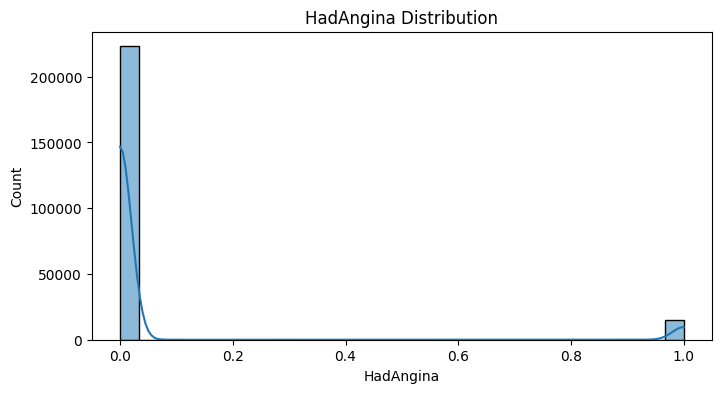

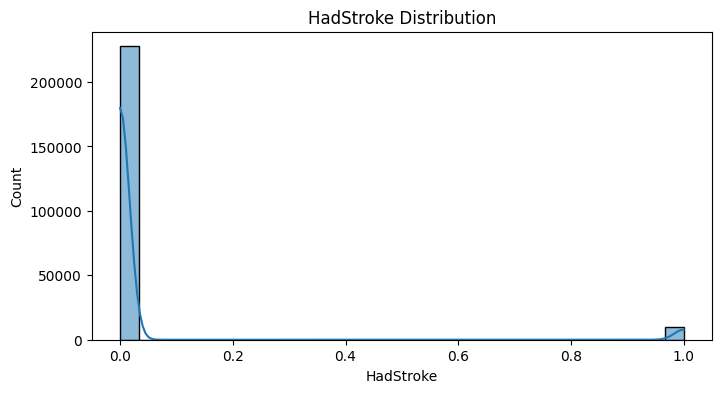

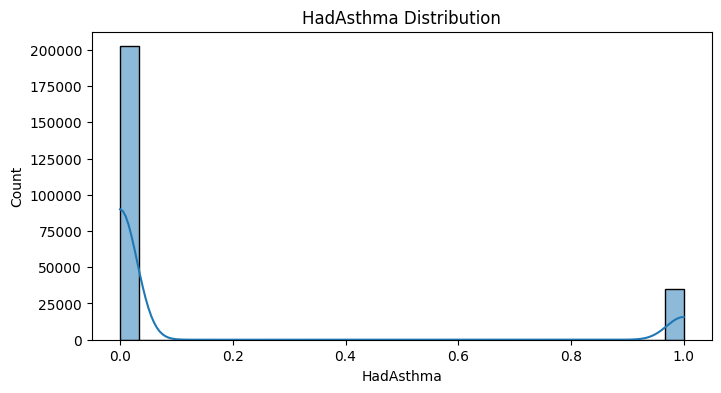

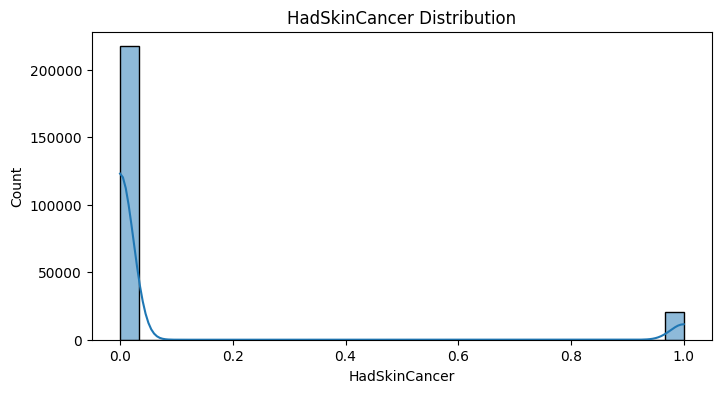

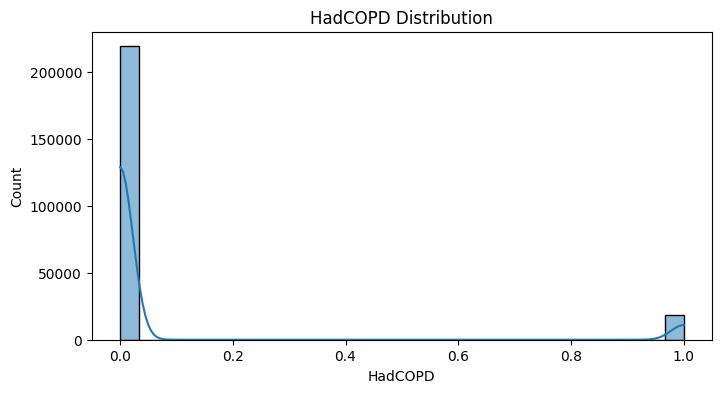

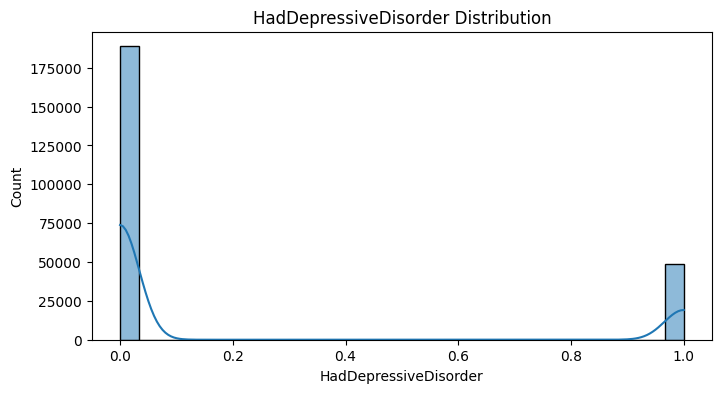

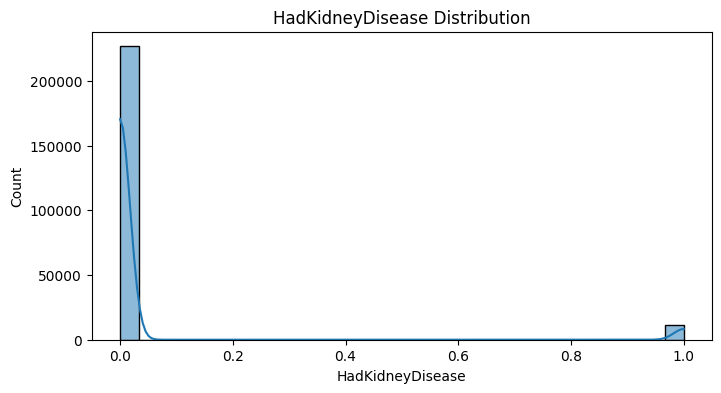

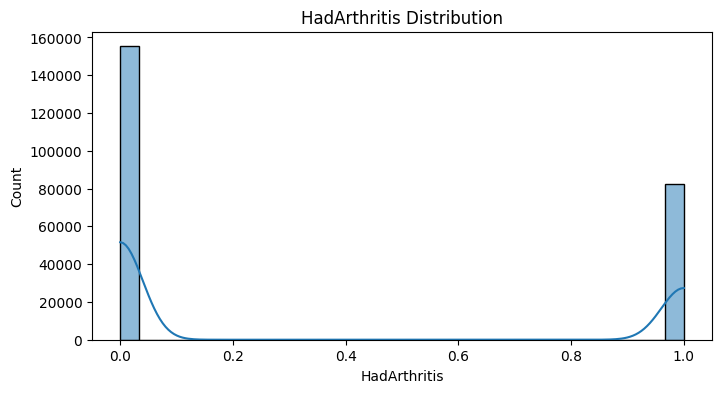

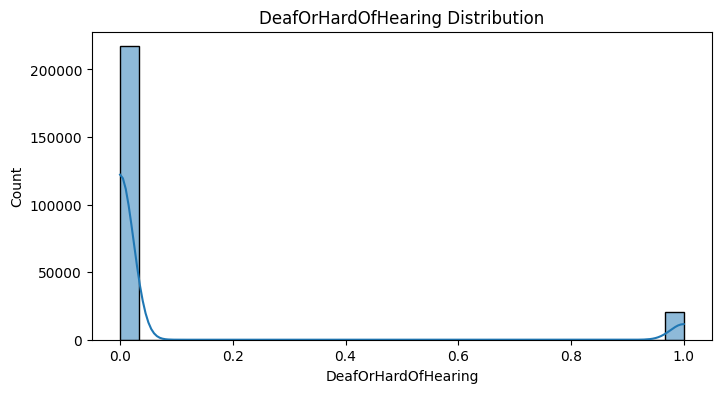

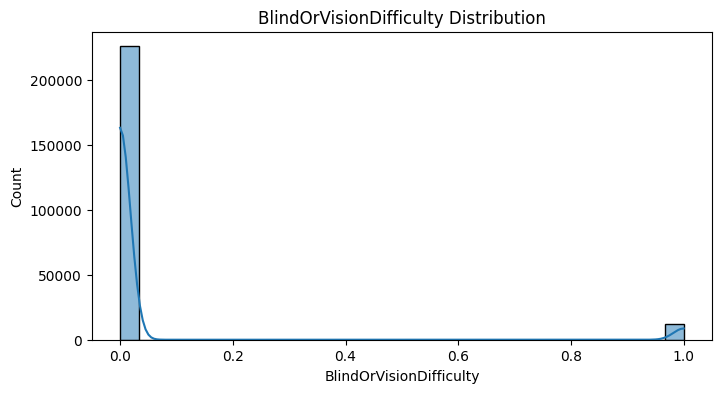

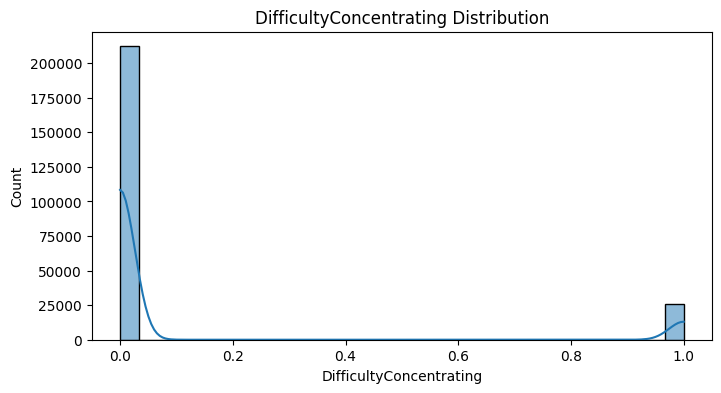

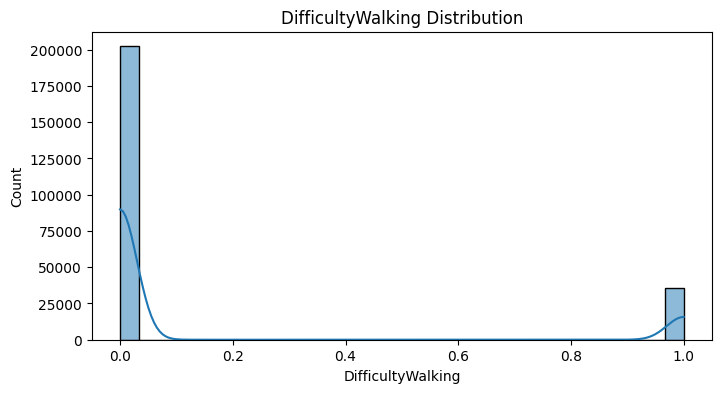

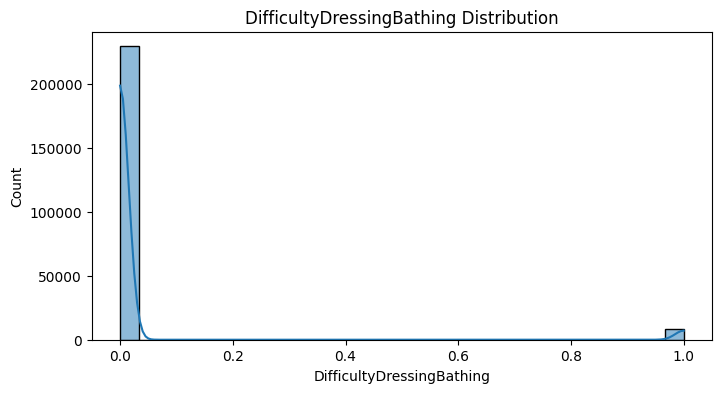

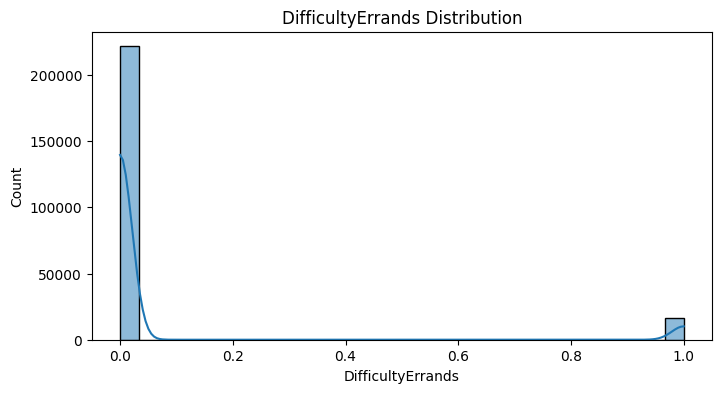

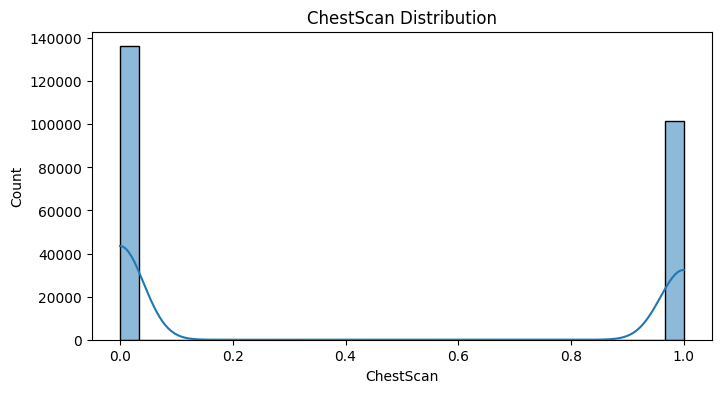

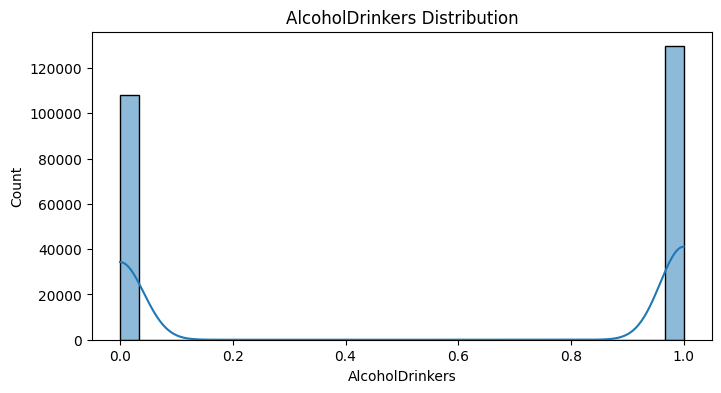

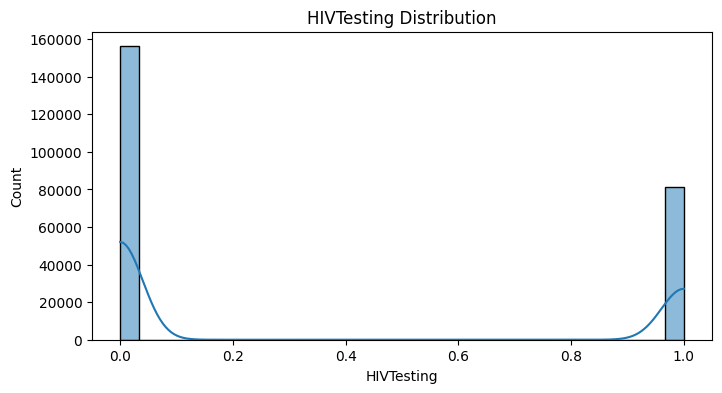

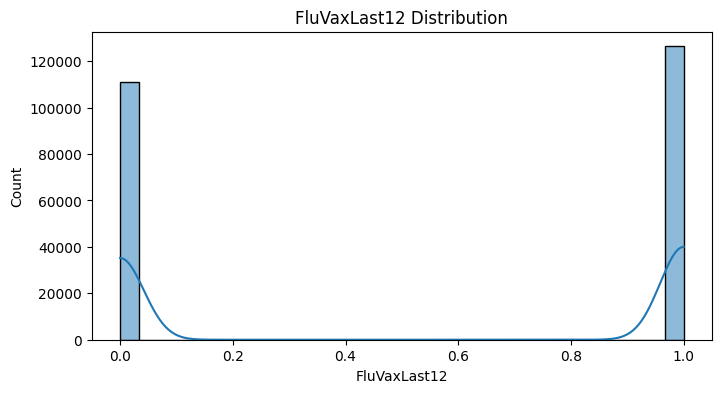

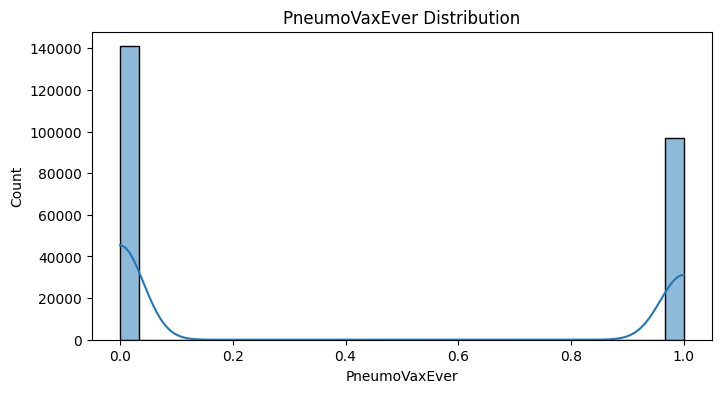

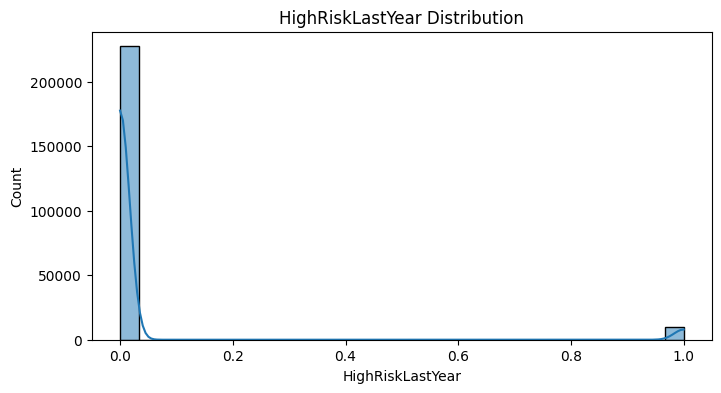

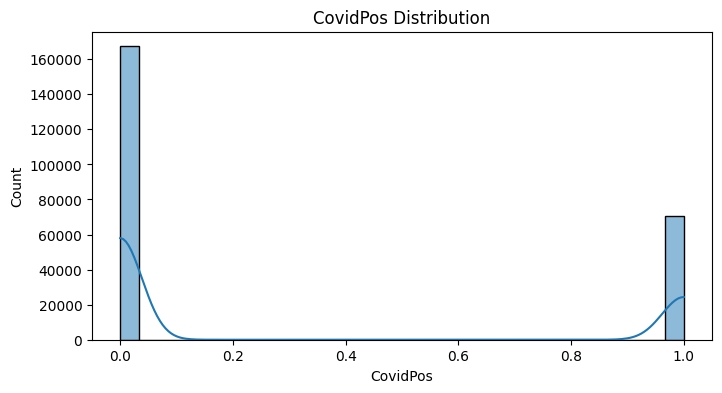

In [ ]:
for col in numeric_cols:
  plt.figure(figsize=(8,4))
  sns.histplot(df[col],bins=30,kde=True)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   tientID                   237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["State"]=le.fit_transform(df["State"])
df["Sex"]=le.fit_transform(df["Sex"])
df["HadDiabetes"]=le.fit_transform(df["HadDiabetes"])
df["SmokerStatus"]=le.fit_transform(df["SmokerStatus"])
df["ECigaretteUsage"]=le.fit_transform(df["ECigaretteUsage"])
df["RaceEthnicityCategory"]=le.fit_transform(df["RaceEthnicityCategory"])
df["TetanusLast10Tdap"]=le.fit_transform(df["TetanusLast10Tdap"])

In [ ]:
print(df["GeneralHealth"].unique())

['Fair' 'Very good' 'Excellent' 'Good' 'Poor']


In [ ]:
# GeneralHealth
df['GeneralHealth'] = df['GeneralHealth'].replace({
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Very good': 4,
    'Excellent': 5
})


/tmp/ipykernel_559/1726086501.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['GeneralHealth'] = df['GeneralHealth'].replace({


In [ ]:
print(df["AgeCategory"].unique())

['Age 75 to 79' 'Age 65 to 69' 'Age 60 to 64' 'Age 70 to 74'
 'Age 50 to 54' 'Age 80 or older' 'Age 55 to 59' 'Age 25 to 29'
 'Age 40 to 44' 'Age 30 to 34' 'Age 35 to 39' 'Age 18 to 24'
 'Age 45 to 49']


In [ ]:
df['GeneralHealth'].replace(['Fair','Very good','Excellent','Good','Poor'],[0,1,2,3,4],inplace=True)
df['AgeCategory'].replace(['Age 75 to 79','Age 65 to 69','Age 60 to 64','Age 70 to 74','Age 50 to 54','Age 80 or older','Age 55 to 59','Age 25 to 29', 'Age 40 to 44','Age 30 to 34','Age 35 to 39','Age 18 to 24', 'Age 45 to 49'],[0,1,2,3,4,5,6,7,8,9,10,11,12],inplace=True)

/tmp/ipykernel_559/1373739301.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GeneralHealth'].replace(['Fair','Very good','Excellent','Good','Poor'],[0,1,2,3,4],inplace=True)
/tmp/ipykernel_559/1373739301.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   tientID                   237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  int64  
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df.isnull().sum()

,0
tientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#SMOTE (over sampling) (used to clear the inbalance, in two ways -over sampling, under sampling)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd
# Features and Target
x = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']

# Apply SMOTE
smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x, y)

# Combine X and Y into one DataFrame
df_resampled = pd.concat(
    [pd.DataFrame(x_resampled, columns=x.columns),
     pd.DataFrame(y_resampled, columns=['HadHeartAttack'])],
    axis=1
)

# Display balanced dataset
print(df_resampled.head())

# Check class distribution
print(df_resampled['HadHeartAttack'].value_counts())

   tientID  State  Sex  GeneralHealth  AgeCategory  HeightInMeters  \
0         1      0    0              2            0            1.63   
1         2      0    0              4            1            1.60   
2         3      0    1              5            2            1.78   
3         4      0    1              4            3            1.78   
4         5      0    0              3            4            1.68   

   WeightInKilograms        BMI  HadAngina  HadStroke  ...  ChestScan  \
0          84.820000  32.099998          1          0  ...          1   
1          71.669998  27.990000          0          0  ...          0   
2          71.209999  22.530001          0          0  ...          0   
3          95.250000  30.129999          0          0  ...          0   
4          78.019997  27.760000          0          0  ...          1   

   RaceEthnicityCategory  AlcoholDrinkers  HIVTesting  FluVaxLast12  \
0                      4                0           0          

In [ ]:
df=df_resampled

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


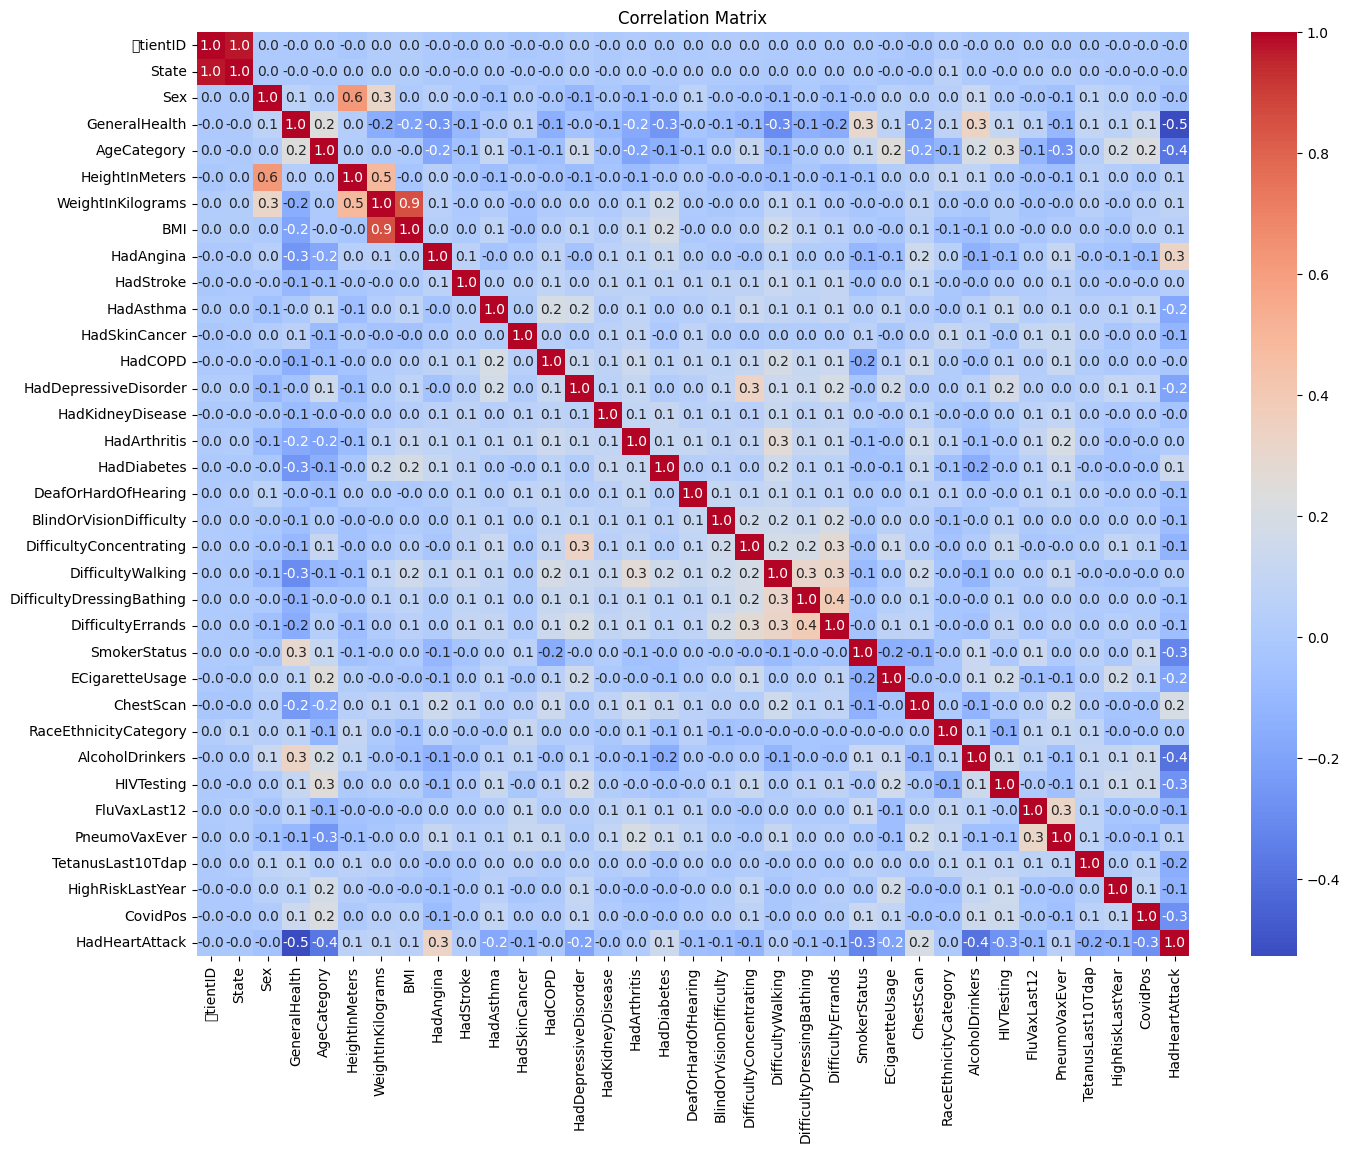

In [ ]:
core_matrix=df.corr()
plt.figure(figsize=(16,12))
sns.heatmap(core_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.drop("WeightInKilograms",axis=1,inplace=True)

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


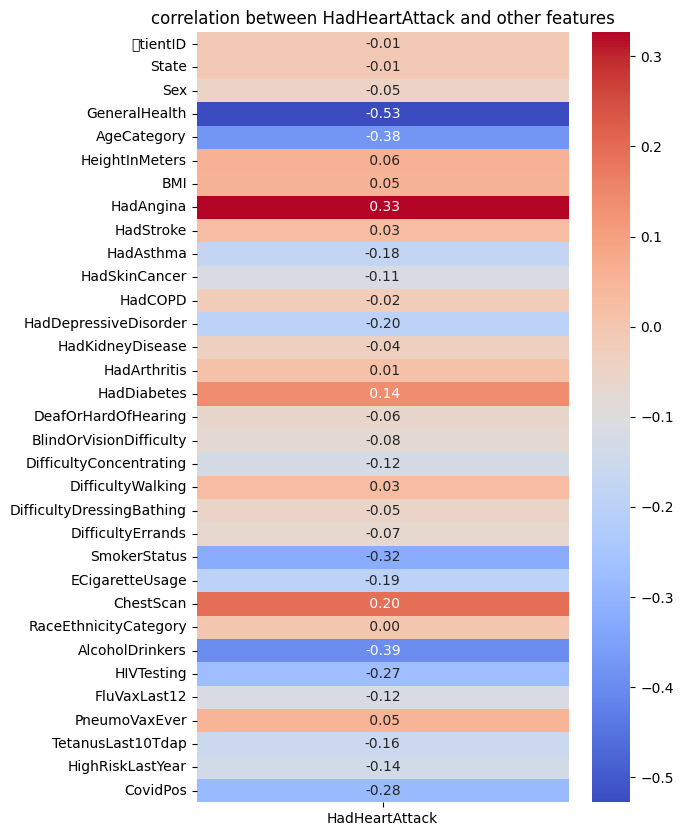

In [ ]:
plt.figure(figsize=(6,10))

status_corr=df.corr()["HadHeartAttack"]
status_corr=status_corr.drop("HadHeartAttack")
sns.heatmap(status_corr.to_frame(), annot=True,fmt=' .2f',cmap='coolwarm',cbar=True, annot_kws={'size':10})
plt.title('correlation between HadHeartAttack and other features')
plt.show()

In [ ]:
df.drop(["tientID","State","TetanusLast10Tdap","HighRiskLastYear","CovidPos","ECigaretteUsage","HadDepressiveDisorder","HeightInMeters"],axis=1,inplace=True)

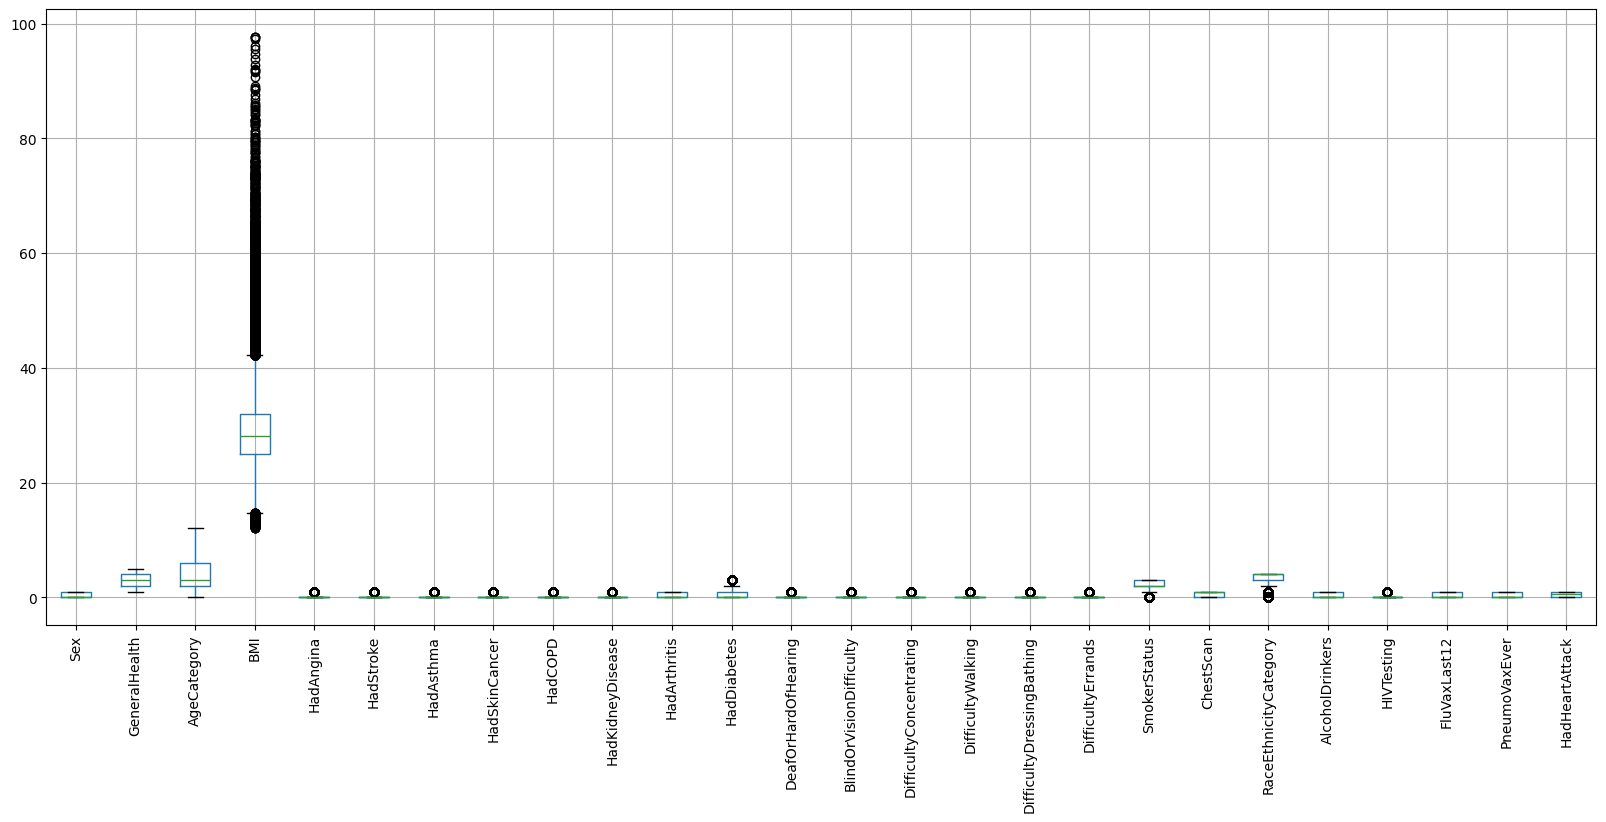

In [ ]:
df.boxplot(figsize=(20,8))
plt.xticks(rotation=90)
plt.show()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
    for col in df.select_dtypes(include=['int64','float64']).columns:
        if col==exclude_column:
            continue

        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)

        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        df=df[(df[col]>=lower) & (df[col]<=upper)]

    return df
df=remove_outliers_iqr(df,exclude_column=target)

In [ ]:
df.shape

(113776, 26)

In [ ]:
df.columns

Index(['Sex', 'GeneralHealth', 'AgeCategory', 'BMI', 'HadAngina', 'HadStroke',
       'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadKidneyDisease',
       'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing',
       'BlindOrVisionDifficulty', 'DifficultyConcentrating',
       'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands',
       'SmokerStatus', 'ChestScan', 'RaceEthnicityCategory', 'AlcoholDrinkers',
       'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'HadHeartAttack'],
      dtype='object')

In [ ]:
features=['Sex', 'GeneralHealth', 'AgeCategory', 'BMI',
       'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadKidneyDisease', 'HadArthritis', 'HadDiabetes',
       'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ChestScan', 'RaceEthnicityCategory', 'AlcoholDrinkers', 'HIVTesting',
       'FluVaxLast12', 'PneumoVaxEver']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
x=df[['Sex', 'GeneralHealth', 'AgeCategory', 'BMI',
       'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadKidneyDisease', 'HadArthritis', 'HadDiabetes',
       'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ChestScan', 'RaceEthnicityCategory', 'AlcoholDrinkers', 'HIVTesting',
       'FluVaxLast12', 'PneumoVaxEver']]
y=df["HadHeartAttack"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.87


# Machine Learning

In [ ]:
#DecisionTree

from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.87


In [ ]:
# SVC

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

# Train
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Pipeline Linear SVC Accuracy: {accuracy:.2f}")

Pipeline Linear SVC Accuracy: 0.87


In [ ]:
#Random forest

from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.89


In [ ]:
#GradientBooster

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)

print("Gradient Boosting Accuracy:",accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8814512726761355


In [ ]:
# ADABOOST
from sklearn.ensemble import AdaBoostClassifier

model=AdaBoostClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.88


In [ ]:
#xgboost

from  xgboost import XGBClassifier

model=XGBClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.90


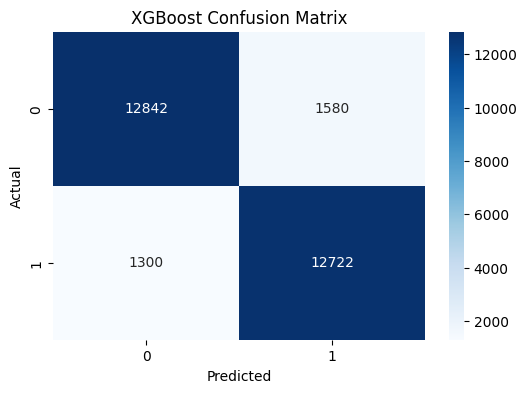

In [ ]:
#Confusion Matrix

cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

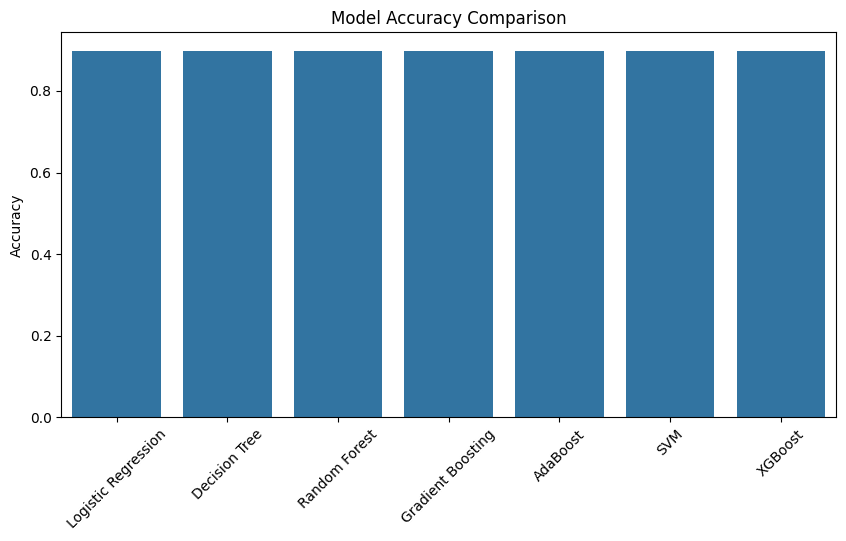

In [ ]:
models=[
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'AdaBoost',
    'SVM',
    'XGBoost']

accuracies=[
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred)]

plt.figure(figsize=(10,5))

sns.barplot(x=models,y=accuracies)

plt.xticks(rotation=45)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

# K-Fold Cross Validation

In [ ]:
X=df.drop('HadHeartAttack',axis=1)
y=df['HadHeartAttack']

kf=KFold(n_splits=5,shuffle=True,random_state=42)

model=LogisticRegression(max_iter=10000)

best_accuracy=0
best_fold=-1

best_x_train=None
best_y_train=None
best_x_test=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(x),1):

    print(f"\nFold {fold}")

    x_train,x_test=x.iloc[train_index],x.iloc[test_index]
    y_train,y_test=y.iloc[train_index],y.iloc[test_index]

    model.fit(x_train,y_train)

    y_pred=model.predict(x_test)

    acc=accuracy_score(y_test,y_pred)

    print("Accuracy:",acc)

    if acc>best_accuracy:

        best_accuracy=acc
        best_fold=fold

        best_X_train=x_train
        best_y_train=y_train

        best_X_test=x_test
        best_y_test=y_test

        best_y_pred=y_pred

print(f"\nBest Fold: {best_fold} with Accuracy: {best_accuracy}")


Fold 1
Accuracy: 0.8686939708208824

Fold 2
Accuracy: 0.8700505383432213

Fold 3
Accuracy: 0.8673258624478136

Fold 4
Accuracy: 0.8734783564051857

Fold 5
Accuracy: 0.8702263238848604

Best Fold: 4 with Accuracy: 0.8734783564051857


In [ ]:
model=LogisticRegression(max_iter=10000)
model.fit(best_X_train,best_y_train)
print("Logistic Regression:",model.score(best_X_test,best_y_test))

Logistic Regression: 0.8734783564051857


In [ ]:
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
print("Random Forest:",model.score(best_X_test,best_y_test))

Random Forest: 0.8928147659854977


In [ ]:
model=DecisionTreeClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Decision Tree:",model.score(best_X_test,best_y_test))

Decision Tree: 0.8726433750823994


In [ ]:
model=SVC()
model.fit(best_X_train,best_y_train)
print("SVM:",model.score(best_X_test,best_y_test))

SVM: 0.8783564051856735


In [ ]:
model=GradientBoostingClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Gradient Boosting:",model.score(best_X_test,best_y_test))

Gradient Boosting: 0.8829268292682927


In [ ]:
model=AdaBoostClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("AdaBoost:",model.score(best_X_test,best_y_test))

AdaBoost: 0.8787519226543616


In [ ]:
model=XGBClassifier(eval_metric='logloss',random_state=42)
model.fit(best_X_train,best_y_train)
print("XGBoost:",model.score(best_X_test,best_y_test))

XGBoost: 0.9005053834322126


In [ ]:
df.shape

(113776, 26)

#Deep Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

model=Sequential()
model.add(Dense(256,input_shape=(x_train_scaled_dl.shape[1],),activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer=Adam(),loss='binary_crossentropy',metrics=['accuracy'])

model.fit(x_train_scaled_dl,best_y_train,epochs=100)

y_pred=model.predict(x_test_scaled_dl)
y_pred=(y_pred>0.5).astype(int)

print(f'\nAccuracy: {accuracy_score(best_y_test,y_pred)}')

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2845/2845 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8747 - loss: 0.2979
Epoch 2/100
2845/2845 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8790 - loss: 0.2875
Epoch 3/100
2845/2845 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8792 - loss: 0.2839
Epoch 4/100
2845/2845 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8819 - loss: 0.2799
Epoch 5/100
2845/2845 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8830 - loss: 0.2765
Epoch 6/100
2845/2845 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8848 - loss: 0.2725
Epoch 7/100
2845/2845 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8870 - loss: 0.2693
Epoch 8/100
2845/2845 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.8879 - loss: 0.2661
Epoch 9/100
2845/2845 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8897 - loss: 0.2631
Epoch 10/100
2845/2845 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8907 - loss: 0.2603
Epoch 11/100
2845/2845 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8927 - loss: 0.2573
Epoch 12/100
2845/2845 ━━━━

#**Conclusion**

A comparison was performed using several machine learning and deep learning models, including Logistic Regression, Decision Tree, Random Forest, SVM, Gradient Boosting, AdaBoost, XGBoost, and an Artificial Neural Network (ANN). Among all the models, XGBoost achieved the highest accuracy of 90.05%, followed by the Deep Learning model with 89.58% and Random Forest with 89.35%. Since XGBoost produced the best prediction results, it was selected as the final model for this study. The results show that XGBoost is the most effective and reliable model for this classification task.

# **Future Scope**

Future work can focus on improving the model by using larger and more diverse datasets, incorporating additional relevant features, and applying advanced machine learning and deep learning techniques. Hyperparameter optimization can be performed to further enhance prediction accuracy and model efficiency. The developed model can also be integrated into real-time applications or decision-support systems for practical use. Additionally, future research may explore explainable AI techniques to improve the transparency and interpretability of predictions, making the model more reliable and user-friendly.